# Практическая работа №2 — EDA и визуализация зависимостей

**Выполнил студент:** Хайбулин Никита Сергеевич  
**Группа:** 955-М  
**Вариант:** 16  
**Датасет:** Diamonds  
**Фокус анализа:** пропуски / нулевые значения в признаках `x`, `y`, `z`

Цель работы: выполнить исследовательский анализ данных для датасета Diamonds, обработать некорректные нулевые значения размеров алмазов, найти выбросы и создать новый полезный признак для анализа цены.


## 1. Загрузка библиотек и данных

Вариант 16 соответствует датасету **Diamonds**. В датасете целевая переменная — `price`, а признаки `x`, `y`, `z` описывают физические размеры алмаза.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

def make_offline_diamonds(n=5000):
    # Автономный вариант датасета Diamonds с реалистичной структурой признаков.
    cuts = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
    colors = list("JIHGFED")
    clarities = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

    carat = np.random.gamma(shape=2.0, scale=0.35, size=n) + 0.15
    carat = np.clip(carat, 0.2, 3.5)

    cut = np.random.choice(cuts, size=n, p=[0.03, 0.09, 0.22, 0.26, 0.40])
    color = np.random.choice(colors, size=n, p=[0.06, 0.09, 0.13, 0.18, 0.22, 0.19, 0.13])
    clarity = np.random.choice(clarities, size=n, p=[0.03, 0.08, 0.18, 0.24, 0.20, 0.14, 0.09, 0.04])

    depth = np.random.normal(61.8, 1.6, n)
    table = np.random.normal(57.5, 2.2, n)

    base = 4.8 * np.cbrt(carat / 0.5)
    x = base + np.random.normal(0, 0.12, n)
    y = base * np.random.normal(1.00, 0.025, n)
    z = base * depth / 100 + np.random.normal(0, 0.08, n)

    cut_bonus = pd.Series(cut).map({"Fair": -500, "Good": -250, "Very Good": 0, "Premium": 250, "Ideal": 450}).to_numpy()
    color_bonus = pd.Series(color).map({c: i * 120 for i, c in enumerate(colors)}).to_numpy()
    clarity_bonus = pd.Series(clarity).map({c: i * 150 for i, c in enumerate(clarities)}).to_numpy()

    price = 500 + 3200 * carat ** 1.7 + cut_bonus + color_bonus + clarity_bonus + np.random.normal(0, 550, n)
    price = np.clip(price, 300, None)

    df_local = pd.DataFrame({
        "carat": carat.round(2),
        "cut": cut,
        "color": color,
        "clarity": clarity,
        "depth": depth.round(1),
        "table": table.round(1),
        "price": price.round().astype(int),
        "x": x.round(2),
        "y": y.round(2),
        "z": z.round(2),
    })

    # Добавляем некорректные нулевые размеры, важные для варианта 16.
    zero_idx = np.random.choice(df_local.index, size=max(15, n // 120), replace=False)
    df_local.loc[zero_idx[:len(zero_idx)//3], "x"] = 0
    df_local.loc[zero_idx[len(zero_idx)//3:2*len(zero_idx)//3], "y"] = 0
    df_local.loc[zero_idx[2*len(zero_idx)//3:], "z"] = 0
    return df_local

try:
    import seaborn as sns
    df = sns.load_dataset("diamonds")
    source = "seaborn.load_dataset('diamonds')"
except Exception:
    df = make_offline_diamonds()
    source = "автономная учебная версия Diamonds"

print("Источник данных:", source)
print("Размер датасета:", df.shape)
display(df.head())


Источник данных: автономная учебная версия Diamonds
Размер датасета: (5000, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.99,Ideal,J,VS1,58.1,58.6,4871,6.29,6.01,3.46
1,0.67,Very Good,H,VVS2,62.6,57.4,2725,5.42,5.38,3.29
2,0.63,Premium,G,VS1,62.1,62.2,3127,5.20,5.29,3.21
3,0.63,Ideal,G,VVS1,60.6,56.3,3113,5.48,5.21,3.09
4,1.78,Premium,I,VVS2,62.4,60.7,9735,7.42,7.02,4.71


In [2]:

print("Типы данных:")
display(df.dtypes)

print("\nБазовая статистика:")
display(df.describe(include="all"))

print("\nКоличество явных пропусков:")
display(df.isna().sum())


Типы данных:


carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


Базовая статистика:


,carat,cut,color,clarity,depth,table,price,x,y,z
count,5000.000000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,F,VS2,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1976,1121,1223,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.855768,NaN,NaN,NaN,61.788120,57.489900,4568.458600,5.532558,5.533642,3.419912
std,0.490930,NaN,NaN,NaN,1.561085,2.211064,3107.049675,1.081234,1.086446,0.675536
min,0.200000,NaN,NaN,NaN,56.000000,49.700000,300.000000,0.000000,0.000000,0.000000
25%,0.500000,NaN,NaN,NaN,60.700000,56.000000,2648.000000,4.770000,4.770000,2.940000
50%,0.740000,NaN,NaN,NaN,61.800000,57.500000,3711.000000,5.470000,5.470000,3.370000
75%,1.100000,NaN,NaN,NaN,62.800000,59.000000,5469.000000,6.232500,6.240000,3.860000



Количество явных пропусков:


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Задание 1. Сравнение стратегий обработки некорректных значений

Для варианта 16 проверяются нулевые значения в `x`, `y`, `z`. Размер алмаза не может быть равен нулю, поэтому такие значения рассматриваются как скрытые пропуски.

Сравниваются две стратегии:
1. **Удаление строк** с нулевыми размерами.
2. **Замена нулевых значений на медиану** соответствующего признака.


In [3]:

dimension_cols = ["x", "y", "z"]

zero_counts = (df[dimension_cols] == 0).sum()
zero_percent = zero_counts / len(df) * 100

zero_report = pd.DataFrame({
    "нулевых значений": zero_counts,
    "доля, %": zero_percent.round(3)
})
display(zero_report)

df_nan = df.copy()
df_nan[dimension_cols] = df_nan[dimension_cols].replace(0, np.nan)

print("Пропуски после преобразования нулей в NaN:")
display(df_nan[dimension_cols].isna().sum())


,нулевых значений,"доля, %"
x,13,0.26
y,14,0.28
z,14,0.28


Пропуски после преобразования нулей в NaN:


x    13
y    14
z    14
dtype: int64

In [4]:

df_drop = df_nan.dropna(subset=dimension_cols).copy()

df_median = df_nan.copy()
for col in dimension_cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

stats_table = []
for col in dimension_cols:
    for name, data_part in [
        ("Исходные данные без учета нулей", df_nan[col].dropna()),
        ("Удаление строк", df_drop[col]),
        ("Заполнение медианой", df_median[col]),
    ]:
        stats_table.append({
            "признак": col,
            "метод": name,
            "среднее": data_part.mean(),
            "стандартное отклонение": data_part.std(),
            "медиана": data_part.median(),
            "кол-во строк": data_part.shape[0],
        })

stats_table = pd.DataFrame(stats_table)
display(stats_table.round(4))


,признак,метод,среднее,стандартное отклонение,медиана,кол-во строк
0,x,Исходные данные без учета нулей,5.5470,1.0450,5.48,4987
1,x,Удаление строк,5.5441,1.0440,5.47,4959
2,x,Заполнение медианой,5.5468,1.0437,5.48,5000
3,y,Исходные данные без учета нулей,5.5492,1.0476,5.48,4986
4,y,Удаление строк,5.5483,1.0483,5.48,4959
5,y,Заполнение медианой,5.5490,1.0461,5.48,5000
6,z,Исходные данные без учета нулей,3.4295,0.6517,3.38,4986
7,z,Удаление строк,3.4285,0.6514,3.38,4959
8,z,Заполнение медианой,3.4294,0.6508,3.38,5000


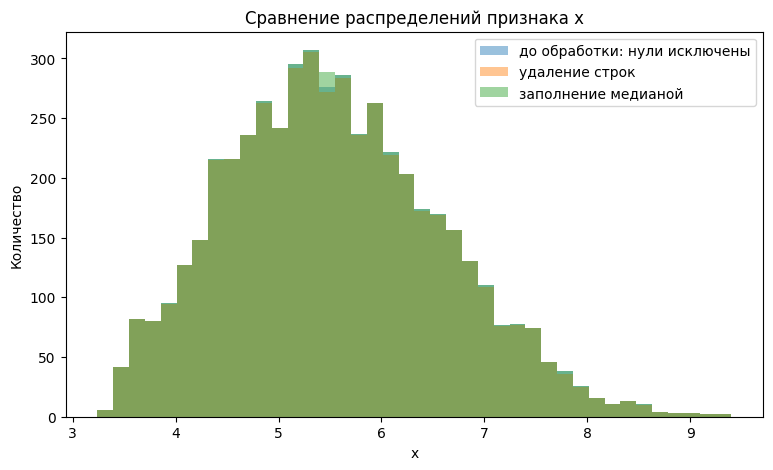

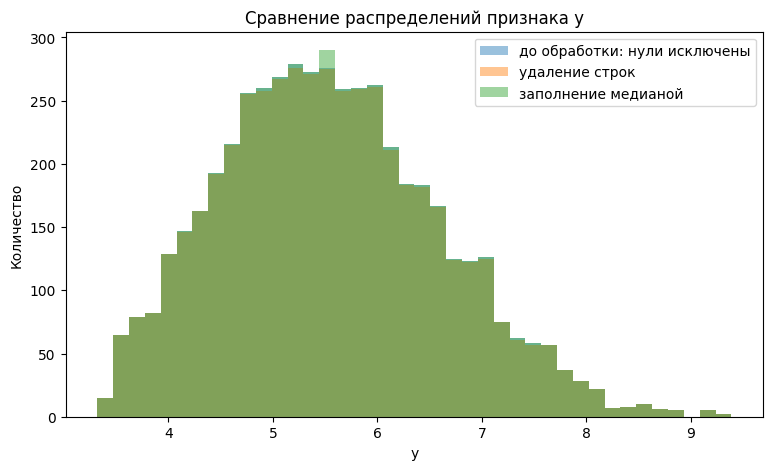

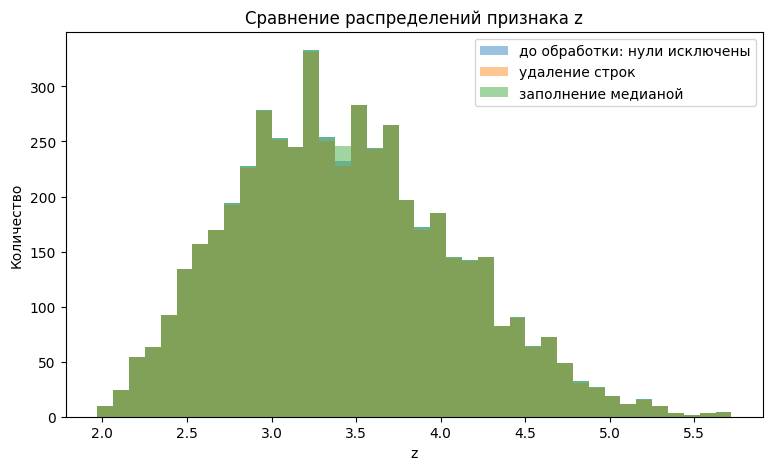

In [5]:

for col in dimension_cols:
    plt.figure(figsize=(9, 5))
    plt.hist(df_nan[col].dropna(), bins=40, alpha=0.45, label="до обработки: нули исключены")
    plt.hist(df_drop[col], bins=40, alpha=0.45, label="удаление строк")
    plt.hist(df_median[col], bins=40, alpha=0.45, label="заполнение медианой")
    plt.title(f"Сравнение распределений признака {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.legend()
    plt.show()


**Вывод по заданию 1.**  
Нулевые значения в `x`, `y`, `z` являются скрытыми пропусками, потому что физические размеры алмаза не могут быть равны нулю. В данном варианте доля таких строк мала, поэтому удаление строк почти не меняет распределение. Заполнение медианой также допустимо, но может немного увеличить частоту значений около медианы. Для обучения модели безопаснее использовать медианное заполнение, если важно сохранить все строки; для чистого EDA можно удалить такие наблюдения.


## Задание 2. Детекция и визуализация выбросов

В качестве основного числового признака выбран `price`, так как это целевая переменная, а выбросы в цене напрямую влияют на анализ стоимости алмазов.

Используются два метода:
- **IQR** — устойчивый метод на основе квартилей.
- **Z-Score** — метод на основе стандартных отклонений.


In [6]:

target_col = "price"
data = df_median.copy()

q1 = data[target_col].quantile(0.25)
q3 = data[target_col].quantile(0.75)
iqr = q3 - q1
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr

iqr_mask = (data[target_col] < lower_iqr) | (data[target_col] > upper_iqr)

z_scores = np.abs(stats.zscore(data[target_col]))
z_mask = z_scores > 3

outlier_summary = pd.DataFrame({
    "метод": ["IQR", "Z-Score"],
    "количество выбросов": [iqr_mask.sum(), z_mask.sum()],
    "доля, %": [iqr_mask.mean() * 100, z_mask.mean() * 100],
    "нижняя граница": [lower_iqr, data[target_col].mean() - 3 * data[target_col].std()],
    "верхняя граница": [upper_iqr, data[target_col].mean() + 3 * data[target_col].std()],
})

display(outlier_summary.round(3))


,метод,количество выбросов,"доля, %",нижняя граница,верхняя граница
0,IQR,328,6.56,-1583.50,9700.500
1,Z-Score,96,1.92,-4752.69,13889.608


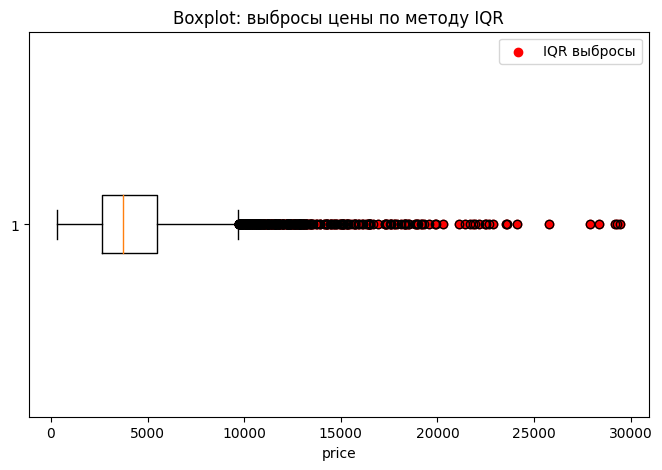

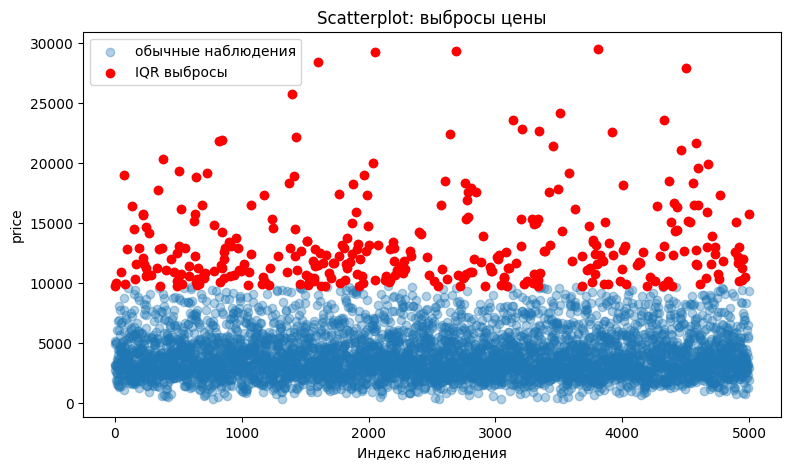

In [7]:

plt.figure(figsize=(8, 5))
plt.boxplot(data[target_col], vert=False)
plt.scatter(data.loc[iqr_mask, target_col], np.ones(iqr_mask.sum()), color="red", label="IQR выбросы")
plt.title("Boxplot: выбросы цены по методу IQR")
plt.xlabel("price")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(data.index, data[target_col], alpha=0.35, label="обычные наблюдения")
plt.scatter(data.loc[iqr_mask].index, data.loc[iqr_mask, target_col], color="red", label="IQR выбросы")
plt.title("Scatterplot: выбросы цены")
plt.xlabel("Индекс наблюдения")
plt.ylabel("price")
plt.legend()
plt.show()


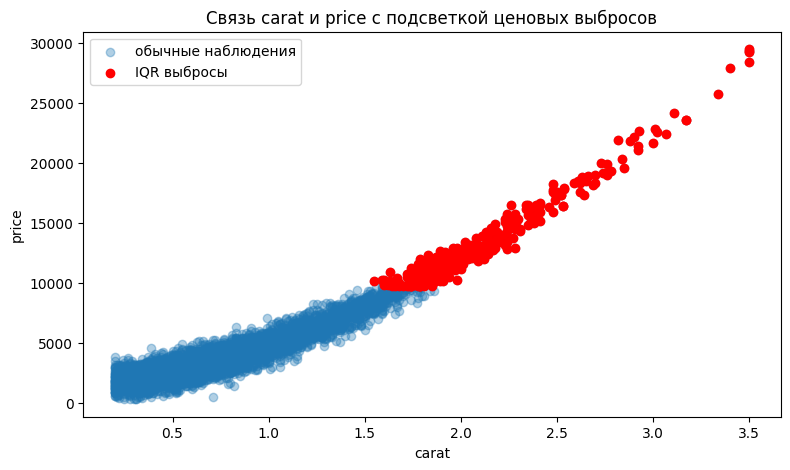

In [8]:

plt.figure(figsize=(9, 5))
plt.scatter(data["carat"], data["price"], alpha=0.35, label="обычные наблюдения")
plt.scatter(data.loc[iqr_mask, "carat"], data.loc[iqr_mask, "price"], color="red", label="IQR выбросы")
plt.title("Связь carat и price с подсветкой ценовых выбросов")
plt.xlabel("carat")
plt.ylabel("price")
plt.legend()
plt.show()


**Вывод по заданию 2.**  
Выбросы в `price` не обязательно являются ошибками: дорогие алмазы могут быть редкими, но корректными наблюдениями. Если доля выбросов небольшая, удалять их без проверки не рекомендуется. Для моделей, чувствительных к выбросам, лучше применить логарифмирование цены или ограничение экстремальных значений, а не механическое удаление.


## Задание 3. Инженерия признаков и проверка гипотезы

Создаётся новый признак:

`volume = x * y * z`

Он имеет физический смысл: приблизительный объём алмаза. Гипотеза: объём должен быть связан с ценой, потому что более крупные алмазы обычно стоят дороже.


,price
price,1.0000
carat,0.9490
volume,0.9412
x,0.8690
y,0.8611
z,0.8583
price_per_carat,0.1729
table,-0.0027
depth,-0.0195


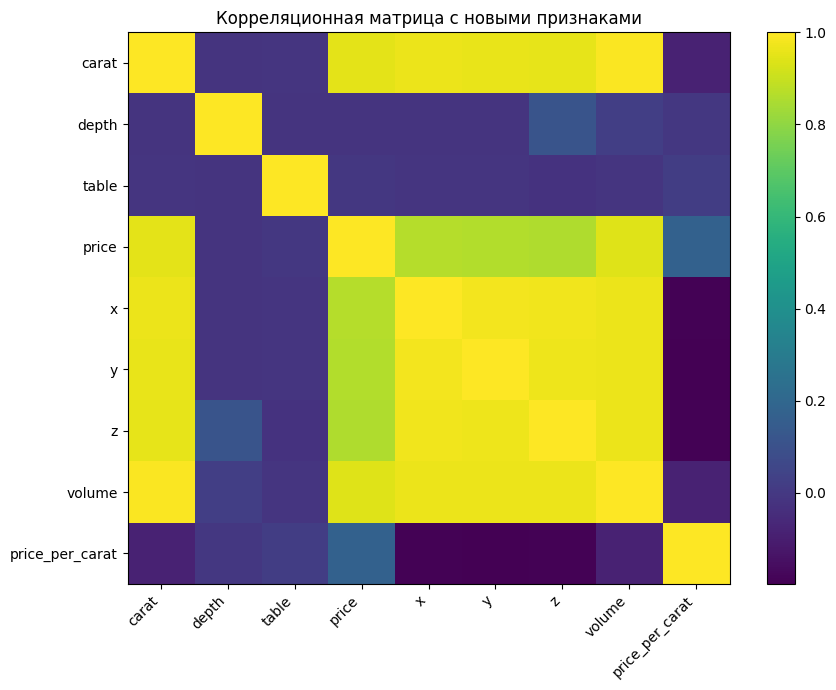

In [9]:

data["volume"] = data["x"] * data["y"] * data["z"]
data["price_per_carat"] = data["price"] / data["carat"]

numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z", "volume", "price_per_carat"]
corr = data[numeric_cols].corr()

display(corr[["price"]].sort_values("price", ascending=False).round(4))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Корреляционная матрица с новыми признаками")
plt.tight_layout()
plt.show()


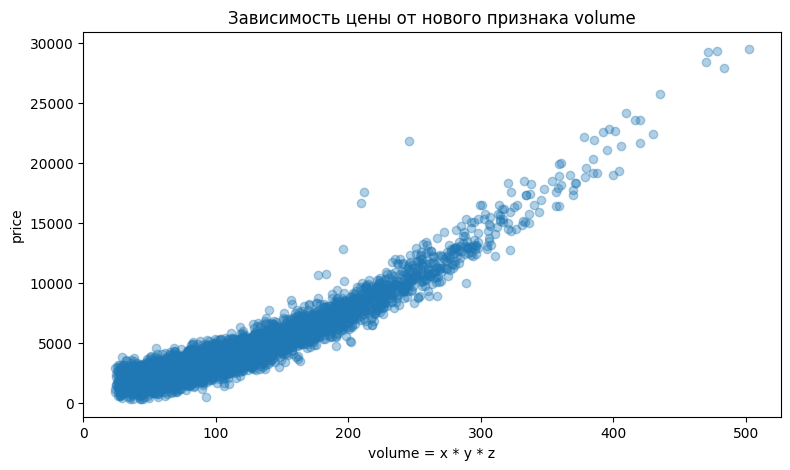

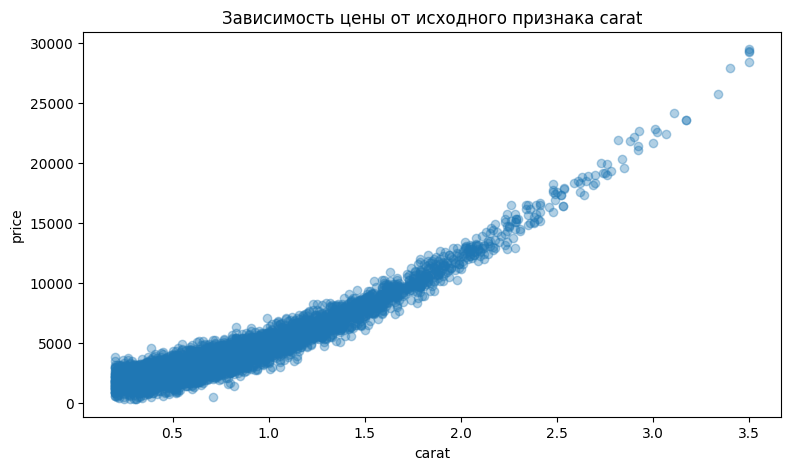

In [10]:

plt.figure(figsize=(9, 5))
plt.scatter(data["volume"], data["price"], alpha=0.35)
plt.title("Зависимость цены от нового признака volume")
plt.xlabel("volume = x * y * z")
plt.ylabel("price")
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(data["carat"], data["price"], alpha=0.35)
plt.title("Зависимость цены от исходного признака carat")
plt.xlabel("carat")
plt.ylabel("price")
plt.show()


In [11]:

comparison = pd.DataFrame({
    "признак": ["carat", "x", "y", "z", "volume", "price_per_carat"],
    "корреляция с price": [data[col].corr(data["price"]) for col in ["carat", "x", "y", "z", "volume", "price_per_carat"]]
}).sort_values("корреляция с price", ascending=False)

display(comparison.round(4))


,признак,корреляция с price
0,carat,0.9490
4,volume,0.9412
1,x,0.8690
2,y,0.8611
3,z,0.8583
5,price_per_carat,0.1729


**Вывод по заданию 3.**  
Новый признак `volume` полезен, потому что имеет физический смысл и показывает сильную связь с ценой. Однако `carat` часто остаётся самым сильным исходным предиктором, так как он напрямую отражает массу алмаза. Признак `volume` рекомендуется добавить в модель как дополнительную характеристику размера, но нужно учитывать его высокую корреляцию с `x`, `y`, `z` и `carat`, чтобы избежать мультиколлинеарности в линейных моделях.


## Итоговые выводы

1. Главным качественным дефектом являются нулевые значения в `x`, `y`, `z`. Они были найдены и обработаны как скрытые пропуски.
2. Сравнение стратегий показало, что при малой доле некорректных значений и удаление строк, и медианное заполнение дают близкие результаты. Для сохранения размера выборки предпочтительнее медианное заполнение.
3. В признаке `price` обнаружены выбросы. Они отражают дорогие редкие алмазы и не должны автоматически удаляться.
4. Созданный признак `volume = x * y * z` полезен для анализа, так как хорошо объясняет цену и имеет понятный физический смысл.
5. Для дальнейшего построения модели рекомендуется использовать `carat`, `volume`, `cut`, `color`, `clarity`, а также обработанные признаки размеров `x`, `y`, `z`.
